In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
import pyarrow.parquet as pq

# Load parquet file
parquet_file = "processedData/cicandmal2020-static.parquet"  # Replace with your actual parquet filename
df = pq.read_table(parquet_file).to_pandas()

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
#print(df.head())
print(df['Label'].value_counts())


In [ ]:


# Updated Label Mapping
label_map = {
    'benign': 0, 'adware': 1, 'backdoor': 2, 'banker': 3, 'dropper': 4,
    'fileinjector': 5, 'NoCategory': 6, 'PUA': 7, 'Ransomware': 8,
    'Riskware': 9, 'SMS': 10, 'Scareware': 11, 'Spy': 12, 'Trojan': 13, 'Zeroday': 14
}

# Load datasets (Replace 'malware_multiclass.csv' with your actual multiclass filename)
benign_df = pd.read_csv("processedData/benign.csv")
mal_df = pd.read_csv("processedData/malware_multiclass.csv") 

# Reset columns to ensure consistency before concatenation
benign_df.columns = range(benign_df.shape[1])
mal_df.columns = range(mal_df.shape[1])

# Concatenate datasets
df = pd.concat([benign_df, mal_df], axis=0, ignore_index=True)

# Ensure feature 9504 contains the integer values 0-14 according to label_map
print("Value counts for multiclass labels:")
print(df[9504].value_counts())


In [2]:
df = pd.read_csv("androfuzz-mlc/balanced_dataset.csv")

In [5]:
print(f"Dataset shape: {df.shape}")
print(df.head)

Dataset shape: (1500, 15)
<bound method NDFrame.head of       app_name  total_methods  version_code  file_size_kb  num_files  \
0         1112          27872     11.000000   4358.369141        105   
1          119            661      7.000000    100.318359         14   
2         1888          12012     45.000000   3272.005859        257   
3         1879              0      2.000000  60780.087891       1341   
4          502           1178      7.000000    616.455078         26   
...        ...            ...           ...           ...        ...   
1495      1444           8178      1.000000    549.711004         11   
1496      1679           1084      1.000000     89.114971         12   
1497      1098             89      1.000000    523.703204        450   
1498      1180           4792     27.745361    491.971894        136   
1499      1331           2096    100.732750    365.561242         70   

      package_name  version_name  num_receivers  num_intents  num_services  \
0

In [6]:
# Convert label column to numeric values using label_map
label_map = {
	'benign': 0, 'adware': 1, 'backdoor': 2, 'banker': 3, 'dropper': 4
}

print(df['label'].value_counts().sort_index())

label
0    150
1    900
2    150
3    150
4    150
Name: count, dtype: int64


In [ ]:
"""label_map = {
    'Benign': 0, 'Adware': 1, 'Backdoor': 2, 'Banker': 3, 'Dropper': 4,
    'FileInfector': 5, 'NoCategory': 6, 'PUA': 7, 'Ransomware': 8,
    'Riskware': 9, 'SMS': 10, 'Scareware': 11, 'Spy': 12, 'Trojan': 13, 'Zeroday': 14
}

Dataset shape: (357805, 9505)
Label
Benign          162181
Riskware         97349
Adware           47210
Trojan           13559
Zeroday          13340
Ransomware        6202
Spy               3540
SMS               3125
Dropper           2302
NoCategory        2296
PUA               2051
Scareware         1556
Backdoor          1538
Banker             887
FileInfector       669
Name: count, dtype: int64
# Normalize mapping keys to lowercase so mixed-case labels still map correctly
df['Label'] = df['Label'].str.lower().map(label_map)
print("Label conversion complete")
print(df['Label'].value_counts().sort_index())"""

In [7]:

X = df.drop('label', axis=1).select_dtypes(include=[np.number])  # also drop hash column (1)
y = df['label']

# Compute correlation of each feature with label
correlations = X.corrwith(y)

# Sort by absolute correlation
corr_sorted = correlations.abs().sort_values(ascending=False)

print(corr_sorted.head(20))

file_size_kb       0.295700
total_methods      0.283510
has_native_code    0.280219
num_files          0.239604
num_activities     0.190680
num_providers      0.187702
num_intents        0.110344
num_receivers      0.100805
num_services       0.080200
app_name           0.077930
version_code       0.047186
num_permissions    0.028968
package_name       0.025440
version_name            NaN
dtype: float64


/home/gentlsnek/MajorProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/gentlsnek/MajorProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
"""
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y)

mi_scores = pd.Series(mi, index=X.columns)
top_features = mi_scores.sort_values(ascending=False).head(50)
"""

In [10]:
TOP_N = 15

top_features = corr_sorted.head(TOP_N).index.tolist()

print("Selected feature indices:", top_features)

Selected feature indices: ['file_size_kb', 'total_methods', 'has_native_code', 'num_files', 'num_activities', 'num_providers', 'num_intents', 'num_receivers', 'num_services', 'app_name', 'version_code', 'num_permissions', 'package_name', 'version_name']


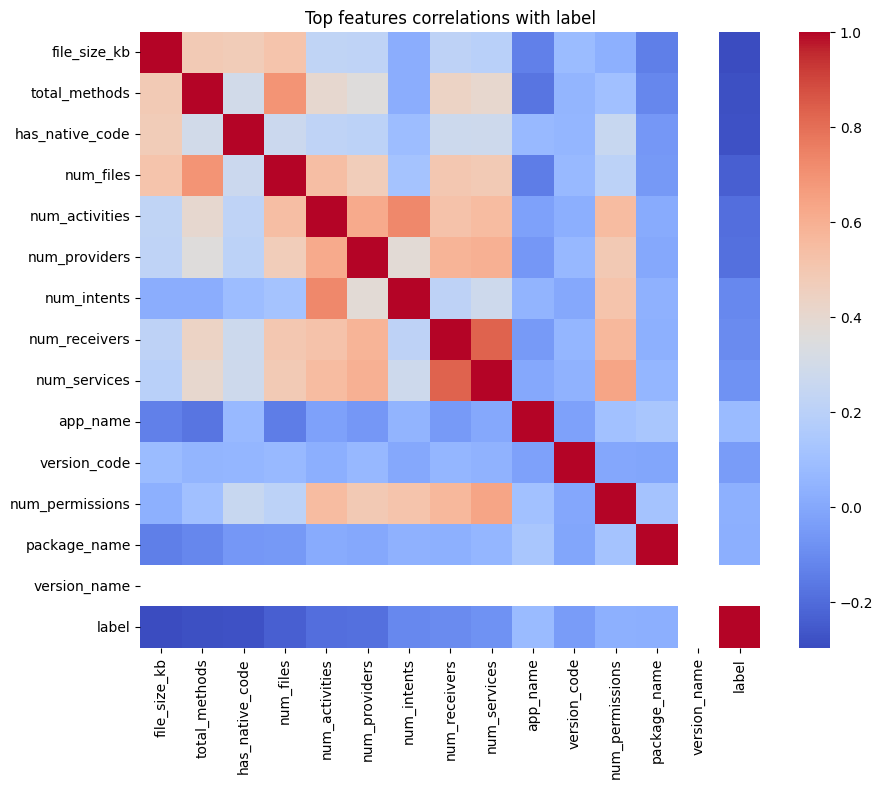

In [11]:


#top_features = mi_scores.sort_values(ascending=False).head(20).index
corr_matrix = df[top_features + ['label']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Top features correlations with label")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Remove rows with NaN labels
valid_indices = y.notna()
X_reduced = X[top_features][valid_indices]
y_clean = y[valid_indices]

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y_clean,
    test_size=0.2,
    stratify=y_clean,
    random_state=42
)

#model - RandomForestClassifier with hyperparameters tuned for multiclass classification
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
target_names = [label_map[i] for i in sorted(label_map.keys())]

print("Multiclass Accuracy:", model.score(X_test, y_test))
print("\nClassification Report:")
inv_label_map = {v: k for k, v in label_map.items()}
target_names = [inv_label_map[i] for i in sorted(inv_label_map.keys())]
print(classification_report(y_test, y_pred, target_names=target_names))

Multiclass Accuracy: 0.9466666666666667

Classification Report:
              precision    recall  f1-score   support

      benign       0.90      0.90      0.90        30
      adware       0.95      0.99      0.97       180
    backdoor       0.94      1.00      0.97        30
      banker       1.00      0.80      0.89        30
     dropper       0.93      0.83      0.88        30

    accuracy                           0.95       300
   macro avg       0.94      0.90      0.92       300
weighted avg       0.95      0.95      0.95       300



In [ ]:
#cross validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_reduced, y_clean, cv=5)
print(scores.mean())

In [13]:
import shap
from sklearn.ensemble import RandomForestClassifier

rf_shap = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10, # Limited depth for faster SHAP calculation
    random_state=42, 
    n_jobs=-1
)
rf_shap.fit(X_train, y_train)

# 2. Initialize the Explainer
# TreeExplainer is optimized specifically for Random Forests
explainer = shap.TreeExplainer(rf_shap)

# 3. Generate SHAP values for a sample
# We use a sample because calculating SHAP for the whole test set is slow
X_sample = X_test.sample(100)
shap_explanations = explainer(X_sample)
shap_values = shap_explanations.values

Generating Detailed Beeswarm for Class 0...


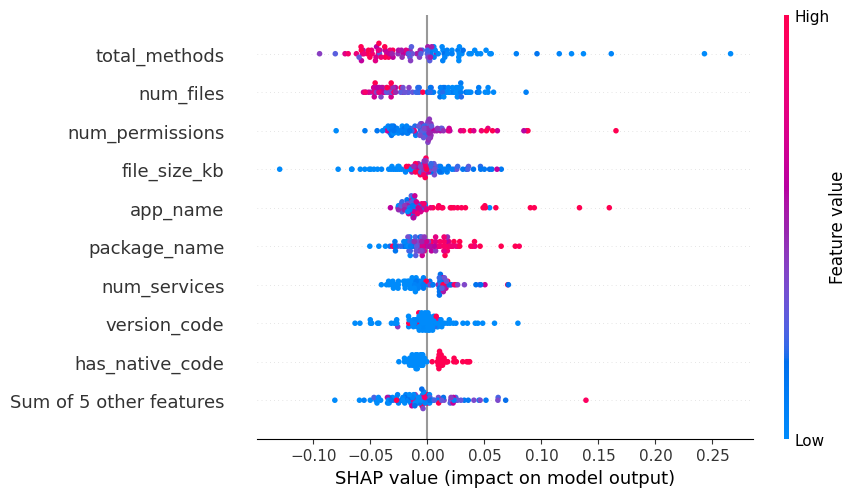

In [14]:
target_class_index = 0
print(f"Generating Detailed Beeswarm for Class {target_class_index}...")
shap.plots.beeswarm(shap_explanations[:, :, target_class_index])

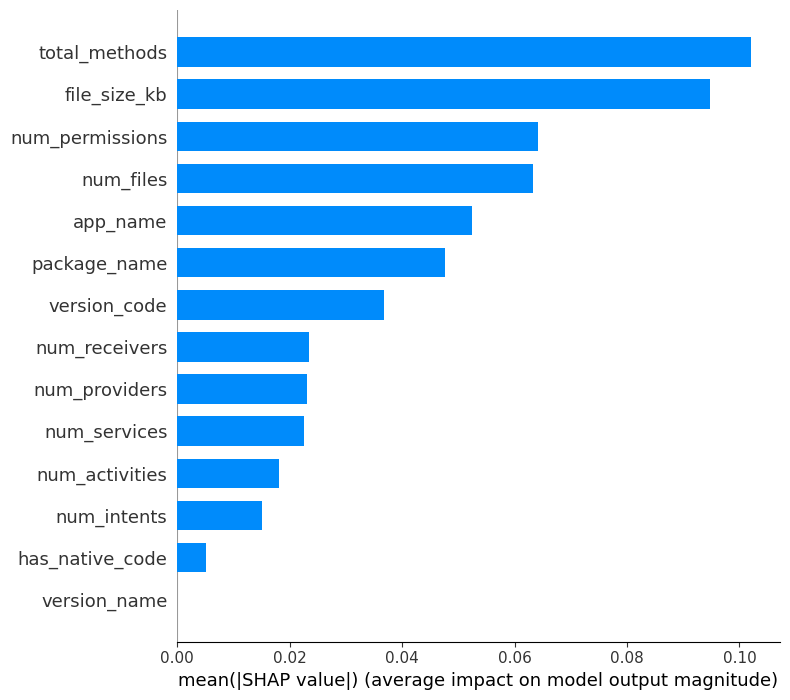

In [15]:
shap.summary_plot(shap_values[:, :, 1], X_sample, plot_type="bar")

Generating explanation for Class: benign (Index 0)


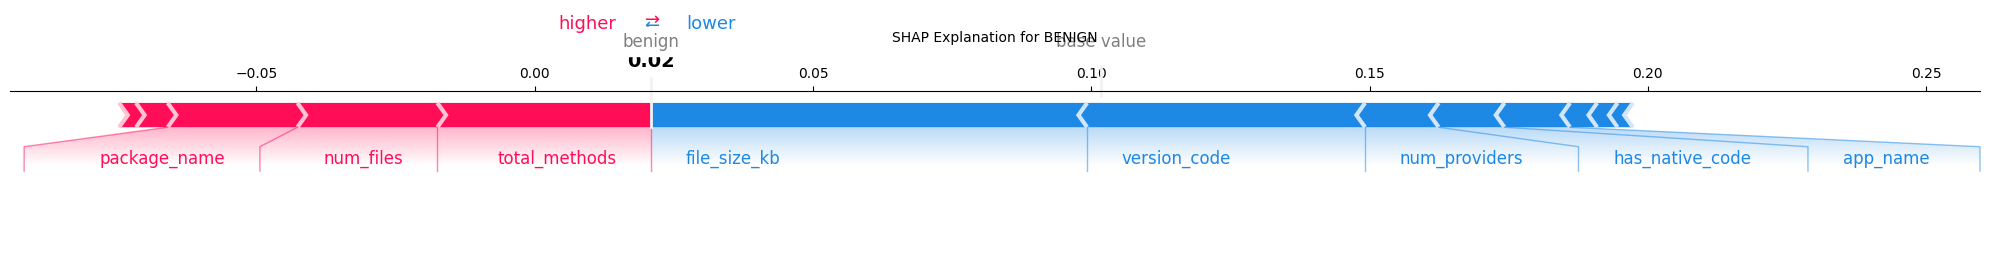

Generating explanation for Class: adware (Index 1)


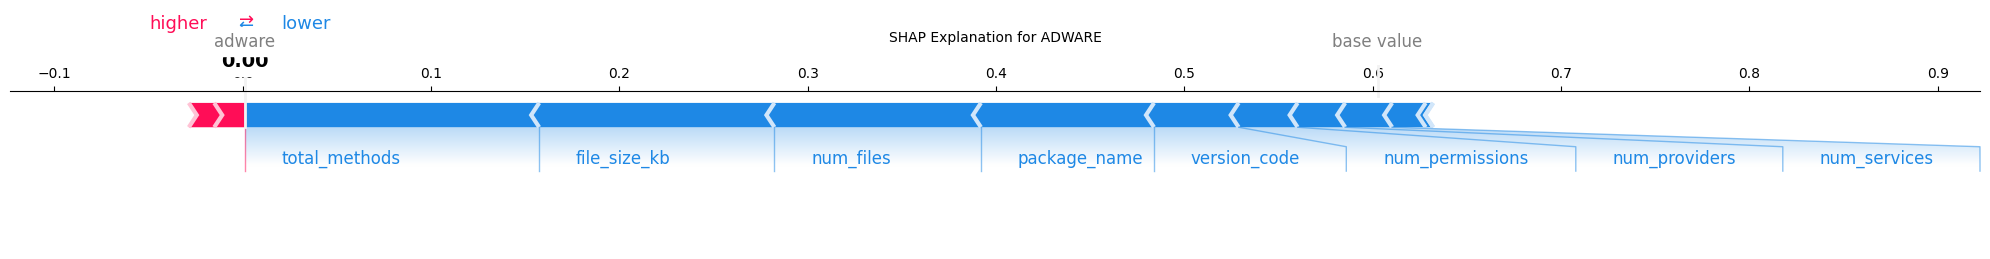

Generating explanation for Class: backdoor (Index 2)


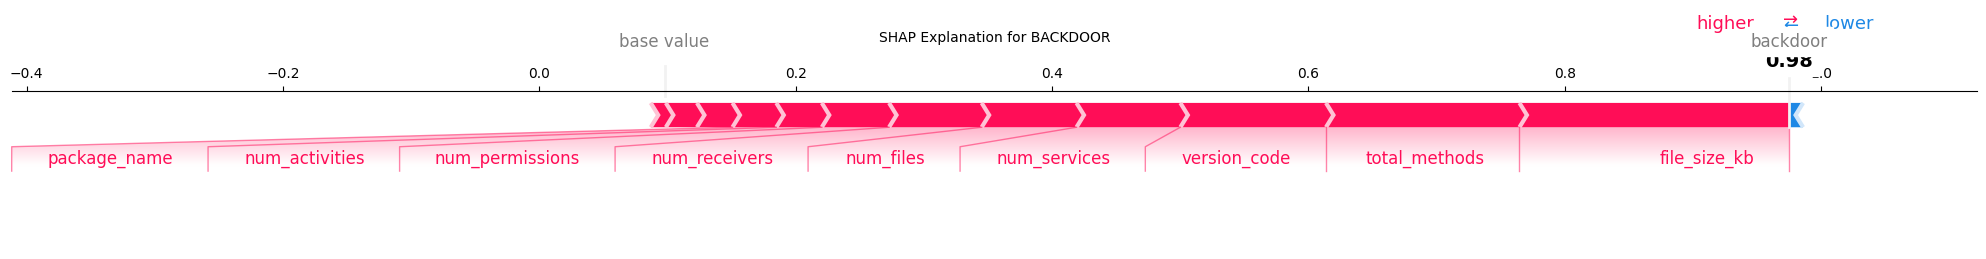

Generating explanation for Class: banker (Index 3)


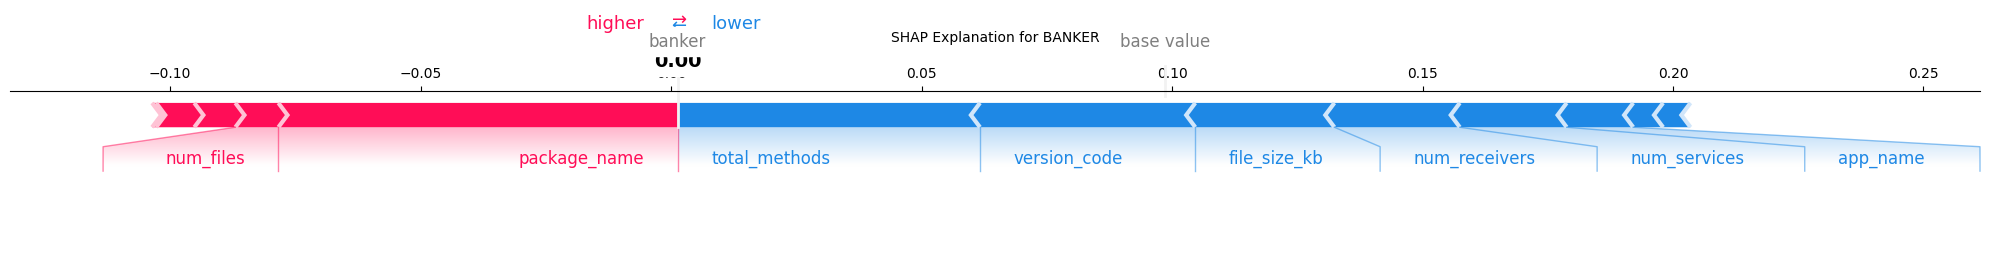

Generating explanation for Class: dropper (Index 4)


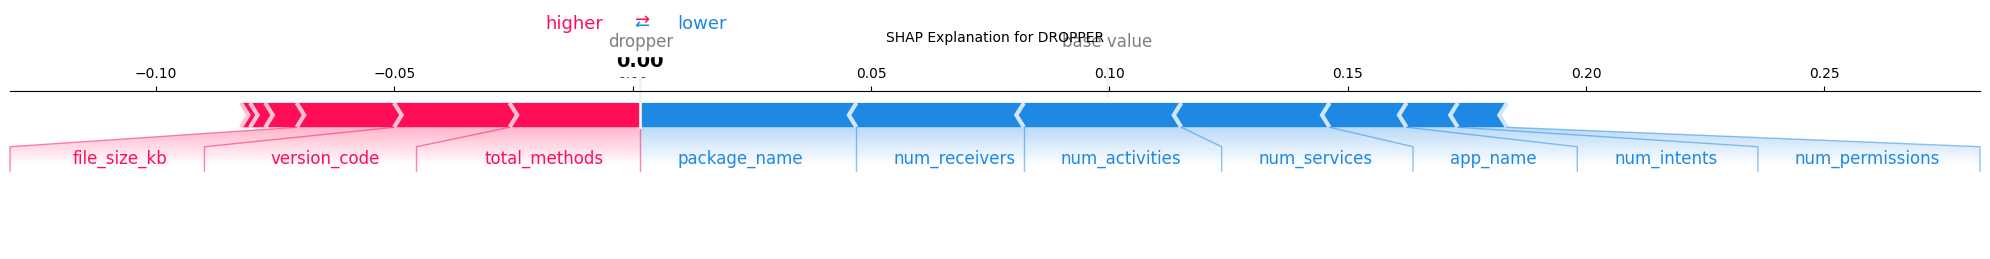

In [16]:
inv_label_map = {v: k for k, v in label_map.items()}



# 2. Select the app and the class you want to explain
i = 0  # Index of the Android app in X_sample


for idx in range(len(inv_label_map)): 
 target_class_index = idx # Example: Explain why it might be 'adware'

# 3. Prepare data for the plot
# Using .astype(float) prevents the UFuncTypeError by ensuring numbers aren't objects
 features_row = X_sample.iloc[i, :]
 feature_names = X_sample.columns.tolist()
 features_display = [str(val) for val in features_row.values]
 class_name = inv_label_map[target_class_index]

# 4. Generate the Force Plot
 print(f"Generating explanation for Class: {class_name} (Index {target_class_index})")

 shap.force_plot(
    float(explainer.expected_value[target_class_index]), 
    shap_values[i, :, target_class_index], 
    features_display,
    feature_names=feature_names,
    out_names=class_name, # This labels the final value as the specific malware type
    matplotlib=True,
    show=False
 )

# 5. Clean up the title and layout
 plt.title(f"SHAP Explanation for {class_name.upper()}", fontsize=10, pad=18)
 plt.tight_layout()
 plt.show()


In [17]:
sample = X_test.sample(n=100, random_state=42).reset_index(drop=True)
pred = model.predict(sample)

# 1. Setup the explainer and explanations
explainer_model = shap.TreeExplainer(model)
# Note: For some RF versions, you might need to use shap_values = explainer.shap_values(sample)
# but the standard explainer call is usually preferred:
shap_explanations_model = explainer_model(sample, check_additivity=False)

# Inverse label map to show names instead of numbers
inv_label_map = {v: k for k, v in label_map.items()}

# 2. Iterate through the predictions
for i, app_pred_idx in enumerate(pred):
    # Convert to integer for indexing
    app_pred_idx = int(app_pred_idx)
    
    # Get the human-readable name of the predicted class
    predicted_class_name = inv_label_map[app_pred_idx]
    
    # DYNAMIC INDEXING: 
    # Get the SHAP values for the specific class that was PREDICTED
    # shap_explanations_model.values shape is (samples, features, classes)
    current_shap_values = shap_explanations_model.values[i, :, app_pred_idx]
    feature_names = sample.columns
    
    # Sort features by their impact (top 3)
    top_indices = np.argsort(np.abs(current_shap_values))[-3:][::-1]
    
    reasons = []
    for idx in top_indices:
        val = current_shap_values[idx]
        feature_name = feature_names[idx]
        
        # If SHAP is positive, it increased the probability of this class
        # If SHAP is negative, it decreased the probability
        if val > 0:
            direction = f"increased evidence for {predicted_class_name}"
        else:
            direction = f"decreased evidence for {predicted_class_name}"
            
        reasons.append(f"{feature_name} ({direction} by {abs(val):.4f})")
        
    print(f"App {i}: Predicted as [{predicted_class_name.upper()}]")
    print(f"   Top Reasons: {', '.join(reasons)}\n")

App 0: Predicted as [ADWARE]
   Top Reasons: total_methods (increased evidence for adware by 0.1970), num_files (decreased evidence for adware by 0.0881), package_name (increased evidence for adware by 0.0753)

App 1: Predicted as [BANKER]
   Top Reasons: version_code (increased evidence for banker by 0.1010), file_size_kb (increased evidence for banker by 0.0907), num_permissions (increased evidence for banker by 0.0660)

App 2: Predicted as [ADWARE]
   Top Reasons: total_methods (increased evidence for adware by 0.1228), num_permissions (increased evidence for adware by 0.1054), file_size_kb (increased evidence for adware by 0.0839)

App 3: Predicted as [DROPPER]
   Top Reasons: file_size_kb (increased evidence for dropper by 0.1178), num_receivers (increased evidence for dropper by 0.0970), num_files (increased evidence for dropper by 0.0777)

App 4: Predicted as [ADWARE]
   Top Reasons: total_methods (increased evidence for adware by 0.1552), file_size_kb (increased evidence for ad

In [ ]:
from xgboost import XGBClassifier

modelx = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    tree_method="hist",
    n_jobs=-1
)

modelx.fit(X_train, y_train)

# Evaluation
y_pred = modelx.predict(X_test)
target_names = [label_map[i] for i in sorted(label_map.keys())]

print("Multiclass Accuracy:", modelx.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))